# Gene Expression Analysis

This project analyzes biological data to identify differences between malignant and benign samples and explores relationships between features using computational methods.

## Goal

The goal of this project is to apply basic data analysis techniques to biological data in order to:

- Identify key features that differentiate malignant and benign samples
- Explore relationships between features
- Demonstrate a systems-level approach to understanding biological data

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

## Loading the Data

The dataset is loaded using a built in dataset from sklearn, which contains measurements related to breast cancer samples.

Each row represents a patient sample and each column represents a biological feature.

The dataset also includes labels indicating whether the sample is malignant or benign.

In [28]:
data = load_breast_cancer()

features = pd.DataFrame(data.data, columns=data.feature_names)
labels = pd.Series(data.target)

features.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Data Structure

The data is divided into two main components:

- Features: Numerical measurements describing biological characteristics
- Labels: The classification of each sample (malignant or benign)

This way we can compare biological conditions and analyze patterns.

In [29]:
print(features.shape)
print(labels.unique())
print(data.target_names)

(569, 30)
[0 1]
['malignant' 'benign']


## Grouping Samples by Condition

The dataset is divided into two groups:

- Malignant samples (cancerous)
- Benign samples (non-cancerous)

This allows us to compare how biological features behave across different conditions.

In [30]:
group_malignant = features[labels == 0]
group_benign = features[labels == 1]

## Differential Feature Analysis

The average value of each feature is calculated for both malignant and benign groups.

The difference between these averages is then computed to identify which features vary the most between the two conditions.

Features with the largest differences are considered the most important for distinguishing between malignant and benign samples.

In [31]:
diff = group_malignant.mean() - group_benign.mean()

top_features = diff.abs().sort_values(ascending=False).head(10)

top_features

worst area         863.386881
mean area          515.586219
worst perimeter     54.364392
area error          51.537257
mean perimeter      37.289971
worst radius         7.755010
worst texture        5.803138
mean radius          5.316306
mean texture         3.690144
perimeter error      2.323608
dtype: float64

## Visualization of Key Features

The top differentiating features are visualized using a bar chart.

This provides a clear representation of which features contribute most to the differences between biological conditions.

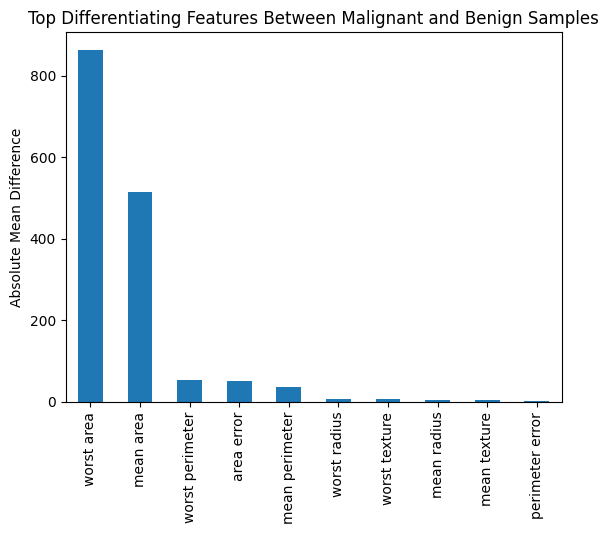

In [32]:
top_features.plot(kind="bar")
plt.title("Top Differentiating Features Between Malignant and Benign Samples")
plt.ylabel("Absolute Mean Difference")
plt.show()

## Correlation Analysis

A correlation matrix is computed to examine relationships between features.

Correlation measures how strongly two features move together.

This step reflects a systems biology perspective, where biological components are analyzed as interconnected systems rather than isolated variables.

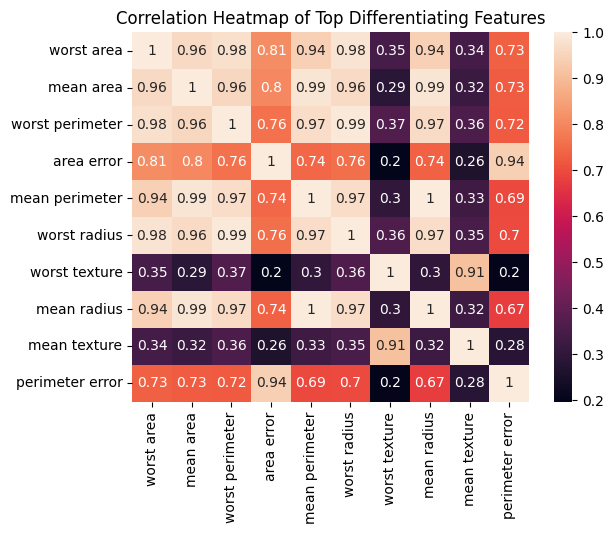

In [33]:
corr = features[top_features.index].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap of Top Differentiating Features")
plt.show()

## Clustering Analysis

KMeans clustering is used to group samples based on their feature values.

This is an unsupervised method, meaning it does not use the known labels.

The goal is to explore whether natural groupings in the data align with biological conditions.

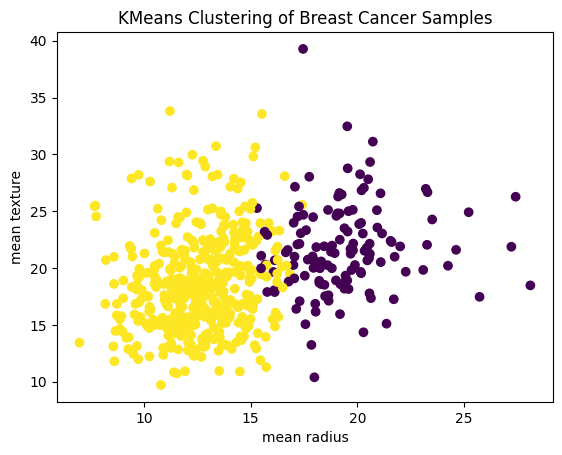

In [34]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(features)

plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=clusters)
plt.xlabel(features.columns[0])
plt.ylabel(features.columns[1])
plt.title("KMeans Clustering of Breast Cancer Samples")
plt.show()

## Conclusion

This project demonstrates how computational methods can be applied to biological data to:

- Identify key differences between conditions
- Explore relationships between features
- Reveal patterns within complex datasets

The approach highlights the importance of data-driven analysis in systems biology and bioinformatics.